# Факторный анализ

# Описание набора данных

Переменные датасета:

1. **Age**: возраст пациента (в годах)

2. **Gender**: пол (женский / мужской)

3. **Medical Condition**: Зарегистрированное состояние здоровья (диабет, гипертония, астма и др.)

4. **Glucose**: Уровень глюкозы в крови в миллиграммах на децилитр (мг/дл) (в США).

5. **Blood Pressure**: Значение артериального давления

6. **BMI**: Индекс массы тела.

7. **Oxygen Saturation**: Уровень насыщения кислородом в крови.

8. **LengthOfStay**: Продолжительность пребывания в больнице (в днях).

9. **Cholesterol**: Уровень холестерина (миллиграммах на децилитр (мг/дл), США)

10. **Triglycerides**: Уровень триглицеридов.

11. **HbA1c**: Гемоглобин A1c (гликированный гемоглобин).

12. **Smoking**: Статус курения (0 = некурящий, 1 = курильщик).

13. **Alcohol**: Употребление алкоголя (0 = Нет, 1 = Да).

14. **Physical Activity**: Физическая активность (примерно часы в неделю).

15. **Diet Score**: Показатель качества диеты (отрицательные значения - плохая диета, положительные значения - хорошая диета).

16. **Family History**: Семейная медицинская история (0 = Нет, 1 = Да).

17. **Stress Level**: Уровень стресса (числовая шкала, от 0).

18. **Sleep Hours**: Количество часов сна в день.

19. **random_notes**: Заметки (lorem / ipsum / ###).

20. **noise_col**: Колонка шума (не связанные случайные значения).

**Датасет содержит 30000 записей.**

# Предварительный анализ данных

Без установки модуля factor_analyzer появится ошибка "ModuleNotFoundError: No module named 'factor_analyzer'.

Установим его

In [ ]:
!pip install factor_analyzer

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

Загрузка датасета из GitHub

In [ ]:
url = "https://raw.githubusercontent.com/Oplot/Healthcare-Risk-Factors-Dataset/main/Healthcare%20Risk%20Factors%20Dataset.csv"
df = pd.read_csv(url)

Посмотрим на данные в датасете.

In [ ]:
print(df)

        Age  Gender Medical Condition  Glucose  Blood Pressure    BMI  \
0      46.0    Male          Diabetes   137.04          135.27  28.90   
1      22.0    Male           Healthy    71.58          113.27  26.29   
2      50.0     NaN            Asthma    95.24             NaN  22.53   
3      57.0     NaN           Obesity      NaN          130.53  38.47   
4      66.0  Female      Hypertension    95.15          178.17  31.12   
...     ...     ...               ...      ...             ...    ...   
29995  54.0  Female           Healthy    86.35          127.68  28.30   
29996  41.0    Male            Asthma    89.24          154.37  24.93   
29997  83.0  Female               NaN      NaN          170.11  30.55   
29998  41.0    Male          Diabetes   242.87          152.97  23.57   
29999  46.0  Female      Hypertension    86.52          159.26  34.55   

       Oxygen Saturation  LengthOfStay  Cholesterol  Triglycerides  HbA1c  \
0                  96.04             6       2

Делаем проверку на пропущенные значения.

In [ ]:
df.info() #позволяет просмотреть количество наблюдений в столбцах и типы данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

Видим, что в датасете всего 20 переменных, среди которых 17 количественных и 3 категориальных (Gender, Medical Condition, random_notes).
При такой проверке выяснилось, что переменные Age, Gender, Medical Condition, Glucose и Blood Pressure содержат меньше значений, чем в остальных переменных.

In [ ]:
#Удаляем пропущенные значения
df = df.dropna().reset_index(drop=True) #.reset_index(drop=True) нужно для того, чтобы обновить индексацию

Дальше нужно проверить на ПОЛНОСТЬЮ дублирующие друг друга строки.

In [ ]:
duplicates = df.duplicated() #проверка на наличие дубликатов
duplicate_indexes = duplicates[duplicates].index.tolist() #выводит индексы, которые можно передать в .drop() для удаления, оставляя 1 уникальное значение в датафрейме
duplicate_indexes

[]

После запуска кода вывелся пустой список - индексов внутри него нет. Это означает, что в датасете нет полностью дублирующихся строк.

In [ ]:
#Удаляем строки с дублирующими индексами
df = df.drop(duplicate_indexes).reset_index(drop=True) #присваеваем напрямую исходному датафрейму
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13355 entries, 0 to 13354
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                13355 non-null  float64
 1   Gender             13355 non-null  object 
 2   Medical Condition  13355 non-null  object 
 3   Glucose            13355 non-null  float64
 4   Blood Pressure     13355 non-null  float64
 5   BMI                13355 non-null  float64
 6   Oxygen Saturation  13355 non-null  float64
 7   LengthOfStay       13355 non-null  int64  
 8   Cholesterol        13355 non-null  float64
 9   Triglycerides      13355 non-null  float64
 10  HbA1c              13355 non-null  float64
 11  Smoking            13355 non-null  int64  
 12  Alcohol            13355 non-null  int64  
 13  Physical Activity  13355 non-null  float64
 14  Diet Score         13355 non-null  float64
 15  Family History     13355 non-null  int64  
 16  Stress Level       133

Изначально было 30000 наблюдений, а теперь имеем 13355. Кажется немного странным, ведь чуть выше в первых пяти переменных было по 25500 наблюдений, значит столько и должно было остаться после операции выше.
dropna() удаляет все строки, где хотя бы одно значение = NaN. Скорее всего, пропуски встречались в нескольких других переменных, включая категориальные.

Чтобы было очевидно, что теперь пропусков нет, воспользуемся командой для подсчёта суммы повторяющихся значений.

In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
Medical Condition,0
Glucose,0
Blood Pressure,0
BMI,0
Oxygen Saturation,0
LengthOfStay,0
Cholesterol,0
Triglycerides,0


Пропусков нет.

In [ ]:
df.columns[df.nunique().eq(1)] #проверка на столбцы с 1 уникальным значением

Index([], dtype='object')

Вывелся пустой массив. Ничего не удаляем.

Проверим уникальные значения

In [ ]:
for columns in df:
  print(columns, df[columns].unique())

Age [46. 22. 66. 50. 13. 32. 60. 74. 45. 64. 78. 63. 58. 82. 33. 73. 39. 53.
 12. 52. 56. 55. 62. 24. 72. 51. 75. 54. 48. 61. 30. 77. 70. 65. 31. 49.
 23. 59. 28. 71. 36. 42. 44. 47. 81. 40. 35. 89. 15. 88. 20. 37. 84. 38.
 67. 76. 79. 43. 83. 27. 57. 21. 29. 80. 18. 69. 19. 34. 68. 41. 25. 86.
 85. 10. 14. 87. 26. 17. 11. 16.]
Gender ['Male' 'Female']
Medical Condition ['Diabetes' 'Healthy' 'Hypertension' 'Asthma' 'Arthritis' 'Obesity'
 'Cancer']
Glucose [137.04  71.58  95.15 ... 211.54 119.96 242.87]
Blood Pressure [135.27 113.27 178.17 ... 191.19 169.77 185.1 ]
BMI [28.9  26.29 31.12 ... 40.02 18.01 41.69]
Oxygen Saturation [ 96.04  97.54  94.9  ... 105.57  82.61  85.57]
LengthOfStay [ 6  2  4  5  1  3  7  8 17 10 12 14 19 15 16 13  9 11 18]
Cholesterol [231.88 165.57 259.53 ... 220.75 158.17 269.29]
Triglycerides [210.56 129.41 115.85 ... 169.61 143.53 224.21]
HbA1c [ 7.61  4.91  5.98  5.48  6.18  4.77  4.3   4.34  8.7   7.68  4.86  6.8
  7.92  7.37  5.53  5.05  5.29  6.09  6.91  5

Качество факториального анализа могут испортить переменные Gender, Medical Condition, random_notes. Эти переменные категориальные.

Переменные Smoking, Alcohol, Family History могут принимать значения "0" и "1", а это слишком узко для факторного анализа.

noise_col убираем тоже, потому что значения этой переменной расценивается как шум (шумовая переменная). Она снижает качество КМО, ухудшает интерпретируемость факторов и не измеряет никакую конструкцию.

Удалим ненужное и выведем датасет в новом виде

In [ ]:
df.drop(['Gender', 'Medical Condition', 'random_notes', 'Smoking', 'Alcohol', 'Family History', 'noise_col'], axis=1, inplace=True) #удаляем переменные, которые могут ухудшить факторный анализ
print(df)

        Age  Glucose  Blood Pressure    BMI  Oxygen Saturation  LengthOfStay  \
0      46.0   137.04          135.27  28.90              96.04             6   
1      22.0    71.58          113.27  26.29              97.54             2   
2      66.0    95.15          178.17  31.12              94.90             4   
3      50.0   107.00          171.80  25.33              95.21             5   
4      13.0    90.60          126.88  29.24              97.96             6   
...     ...      ...             ...    ...                ...           ...   
13350  33.0   119.96          137.34  33.15              92.07             5   
13351  54.0    86.35          127.68  28.30              94.36             1   
13352  41.0    89.24          154.37  24.93              96.07             4   
13353  41.0   242.87          152.97  23.57              99.17             3   
13354  46.0    86.52          159.26  34.55              96.60             4   

       Cholesterol  Triglycerides  HbA1

Теперь посмотрим на описательную статистику, чтобы проверить на наличие "странных" значений

In [ ]:
df.describe().round(2)

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Physical Activity,Diet Score,Stress Level,Sleep Hours
count,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00,13355.00
mean,54.62,123.70,140.26,28.48,94.92,4.39,212.94,176.97,6.30,3.83,4.04,5.90,6.24
std,15.88,41.70,21.09,5.76,3.75,2.71,33.74,48.57,1.33,2.03,1.82,2.21,1.19
min,10.00,20.32,74.24,9.40,67.51,1.00,95.73,-8.14,3.46,-2.00,-1.75,-2.07,1.59
25%,45.00,96.24,125.01,24.58,93.00,3.00,189.06,141.52,5.33,2.37,2.78,4.35,5.42
50%,55.00,110.62,138.11,28.05,95.25,4.00,211.68,173.41,5.97,3.60,3.80,5.87,6.23
75%,66.00,137.05,153.79,31.81,97.35,5.00,235.44,208.42,6.92,5.10,5.03,7.43,7.08
max,89.00,318.51,224.25,52.86,110.07,19.00,355.27,421.51,11.94,12.41,12.06,13.92,10.35


1. Triglycerides - есть неправильное значение (min = -8.14). Триглицериды не могут быть отрицательными. Это ошибка.
2. Physical Activity - есть отрицательные значения (min = -2.00). Это тоже ошибка.
3. Oxygen Saturation - есть нереалистичное значение (max = 110.07%), хотя максимальное значение может быть равно не более 100%.
4. Stress Level - нереалистично при min = -2.07 (тут шкала от 0).

Переведём "странные" значения в NaN.

In [ ]:
# 1. Triglycerides: отрицательные - NaN
df.loc[df['Triglycerides'] < 0, 'Triglycerides'] = np.nan

# 2. Physical Activity: отрицательные - NaN
df.loc[df['Physical Activity'] < 0, 'Physical Activity'] = np.nan

# 3. Oxygen Saturation: > 100 - NaN
df.loc[df['Oxygen Saturation'] > 100, 'Oxygen Saturation'] = np.nan

# 4. Stress Level: отрицательные - NaN
df.loc[df['Stress Level'] < 0, 'Stress Level'] = np.nan

А теперь нужно удалить значения с NaN через dropna(), чтобы остались строки с конкретными данными.

In [ ]:
df = df.dropna().reset_index(drop=True)
df.shape

(12388, 13)

А теперь выведем ту же описательную статистику, только уже без "странных" значений.

In [ ]:
df.describe().round(2)

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Physical Activity,Diet Score,Stress Level,Sleep Hours
count,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00,12388.00
mean,54.71,123.67,140.31,28.42,94.50,4.39,213.01,176.77,6.30,3.89,4.05,5.93,6.24
std,15.88,41.76,21.13,5.73,3.48,2.70,33.81,48.21,1.33,1.98,1.83,2.20,1.19
min,10.00,20.32,76.34,9.40,67.51,1.00,95.73,4.00,3.46,0.00,-1.75,-0.00,1.59
25%,45.00,96.20,125.02,24.54,92.83,3.00,189.02,141.51,5.33,2.43,2.78,4.37,5.42
50%,55.00,110.62,138.12,27.98,95.00,4.00,211.70,173.08,5.97,3.64,3.81,5.89,6.22
75%,66.00,137.07,153.93,31.74,96.94,6.00,235.63,208.17,6.92,5.14,5.05,7.44,7.08
max,89.00,318.51,224.25,52.86,100.00,19.00,355.27,386.66,11.94,12.41,12.06,13.92,10.35


Теперь у нас нет "странных" значений в датасете.

Пройдёмся по средним значениям:
1. Age = 54.71
2. Glucose = 123.67
3. Blood Pressure = 140.31
4. BMI = 28.42
5. Oxygen Saturation = 94.50
6. LengthOfStay = 4.39
7. Cholesterol = 213.01
8. Triglycerides = 176.77
9. HbA1c = 6.30
10. Physical Activity = 3.89
11. Diet Score = 4.05
12. Stress Level = 5.93
13. Sleep Hours = 6.24

Всё в норме. Можно идти дальше.

# Разведочный анализ

В разведочном анализе проводим статистический анализ данных: выявляем взимосвязи, определяем тип распределения данных, осуществляем анализ выбросов

Строим корреляционную матрицу

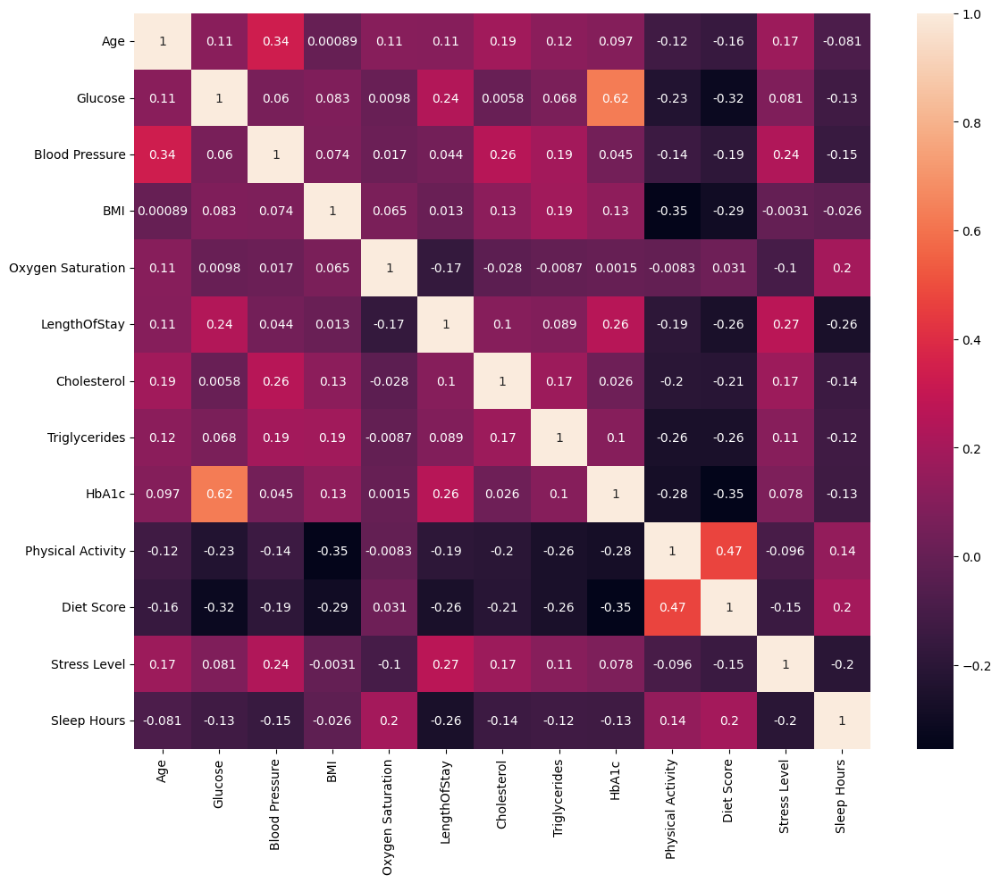

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(df.corr(), annot=True)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()



Почти все корреляции слабые. Большинство значений находятся между -0.2 и 0.2. Лишь отдельные пары поднимаются до 0.4-0.6, но их крайне мало.
Это означает, что высокой мультиколлинеарности нет.

Разберём заметные связи:
1. Glucose - HbA1c = 0.62. Это логично, потому что HbA1c отражает средний уровень глюкозы, а Glucose - это мементальный её уровень. Подтверждает адекватность данных.
2. Diet Score - Physical Activity = 0.47. Лучшее значение диеты у тех, у кого больше физической активности.
3. Sleep Hours - Stress Level = -0.2. Чем меньше сна, тем выше уровень стресса.
4. Glucose - Diet Score = -0.32. Чем выше от нормы уровень глюкозы в крови, тем хуже оценка диеты (по своей шкале). Это факт.
5. BMI - Physical Activity = -0.35. Чем меньше физической активности, тем больше индекс массы тело и тем больше вероятность ожирения.

Все эти и другие факторы в матрице говорят о том, что в датафрейме всё логично. "Странных" значений не осталось после очистки данных.

Анализ квантильных групп

В .describe() приводятся стандартные квантилии, а в .quantile() даётся возможность анализировать детальнее и представлять иные квантильные значения

In [ ]:
df.quantile([0.1, 0.9]).round(2) #квантили

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Physical Activity,Diet Score,Stress Level,Sleep Hours
0.1,32.0,84.94,114.75,21.57,90.26,2.0,170.17,118.35,4.94,1.51,1.97,3.10,4.7
0.9,75.0,191.20,169.37,35.86,98.38,7.0,257.42,240.84,8.37,6.65,6.59,8.82,7.8


Первые 10% людей моложе 32 лет, имеют уровень глюкозы ниже 85, артериальное давлени ниже 115, индекс массы тела ниже 21.6 (худые, норма), кислород на уровне 90.3 (показатель респираторного нарушения), продолжительность нахождения в больнице <= 2 дней, холестерин 170, триглицерид 118, HbA1c ниже 4.9, физическая активность 1.5 часов в день, оценка уровня диеты - около 2, уровень стресса - 3, количество часов сна <= 4.7.

С другой стороны, последние 10% людей старше 75 лет, имеют уровень глюкозы в кровеи 191.2 (диабетический уровень), артериальное давление - 170 (конкретная гипертония), индекс массы тела - выше 35.8 (явное ожирение 2й степени), кислород на уровне 98.4, лежат в больнице более 7 дней, холестирин - выше 257 (есть выраженная дислипидемия), триглицерид - выше 240 (гипертриглицеридемия), HbA1c - выше 8.37 (некотролируемый диабет), физическая активность - 6.6 часов в день (очень много, но такие значения реальны), оценка уровня диеты - 6.6, уровень стресса - 8.8, сон - 7.8 часов в день (норма).

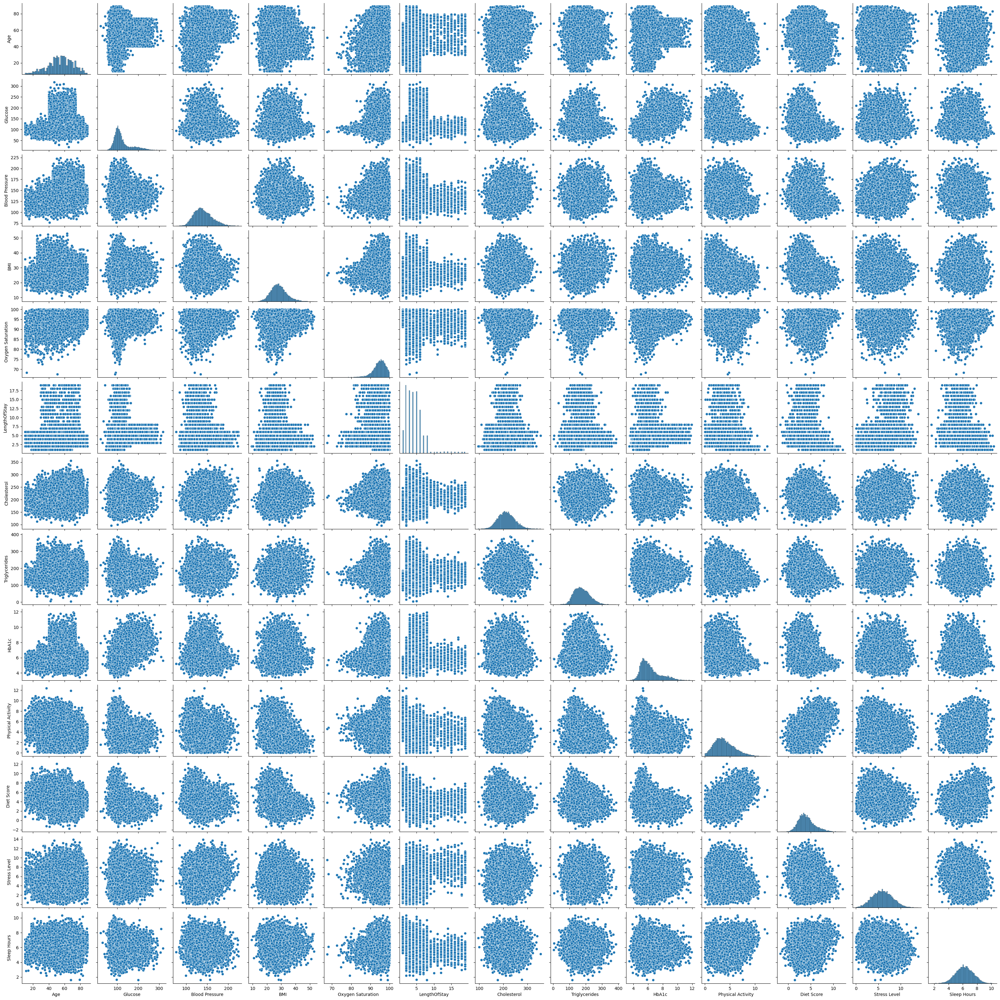

In [ ]:
sns.pairplot(df)
plt.show()

На графиках видно, что глюкоза, триглицериды, холестирин, HbA1c, давление, BMI - правосторонне скошены (много значений около нормы и имеется длинный "хвост" вверх). Нормальность отсутствует. Между признаками почти нет сильных связей. Небольшие положительные связи наблюдаются между глюкозой и HbA1c, а также между триглицеридами и холестирином.

Анализ выбросов

1. Сделаем визуализацию и удаление выбросов (если нужно будет) с помощью ящиков с усами

In [ ]:
#Можно вывести все сразу переменные
px.box(df)

Это неинформативно, поэтому лучше рассматривать либо попарно те величины, которые находятся примерно в одном диапазоне значений, либо отдельно.

In [ ]:
px.box(df['Age'], title='Ящик с усами с выбросами') #вывод для Age

В распределении возраста выбросов нет. Внизу есть отдельные точки 10-15, но это является нормой.

In [ ]:
px.box(df['Glucose'], title='Ящик с усами с выбросами') #вывод для Glucose

Здесь выбросы есть. Нижние точки (20-40) - аномально низкие значения, много точек сверху (200+) - это аномально высокие значения, которые точно будут выбросами.
50-200 миллиграмм на децилитр (мг/дл) (в США) - это значения, которые принимает глюкоза.

Границы усов определяются, как Q1 - 1.5×IQR и Q3 + 1.5×IQR, где IQR - межквартильный размах (Q3-Q1). Следовательно, то, что выше или ниже этих границ, является аномальным значением.

In [ ]:
def removal_box_plot_px(df, column, lower, upper):
    # оставляем только допустимые значения
    cleaned_df = df[(df[column] >= lower) & (df[column] <= upper)]

    fig = px.box(cleaned_df, y=column,
                 title=f'Ящик с усами без выбросов ({column})')
    fig.show()

    return cleaned_df

# оставляем границы
lower_bound = 50
upper_bound = 200

df_clean = removal_box_plot_px(df, 'Glucose', lower_bound, upper_bound)


Значения > 170 могут быть, если анализы брались после еды (после 2 часов), поэтому значения выше этого числа оставляем. К тому же, возможны какие-либо особенности организма человека, из-за чего остаются точки выше верхнего уса.

In [ ]:
px.box(df['Blood Pressure'], title='Ящик с усами с выбросами') #вывод для Blood Pressure

Выбросов нет, так как значения 200-220 являются гипертонией. Да, это не норма для человека, но такие данные говорят о том, что в датасете есть люди с подобными проблемами.
Значение - 76 говорит о том, что есть человек с гипотонией (пониженное давление < 100). Оставляем как есть.

In [ ]:
px.box(df['BMI'], title='Ящик с усами с выбросами') #вывод для BMI

Казалось бы, выбросы есть, но удалять ничего не нужно. Есть люди с крайней анорексией и крайним ожирением.

In [ ]:
px.box(df['Oxygen Saturation'], title='Ящик с усами с выбросами') #вывод для Oxygen Saturation

Та же самая ситуация. В медицине насыщение кислоробом ниже 90% прямо считается гипоксией, а значения от 65% - это состояние, при котором человек ещё живой, но ему срочно требуется помощь. При значении 67.51 замер мог производиться при резком ухудшении здоровья человека. Такая ситуация реальна в жизни, поэтому удалять ничего не будем.

Такое возможно при тяжёлой пневмонии, дыхательной недостаточности, храническими заболеваниями лёгких.

In [ ]:
px.box(df['LengthOfStay'], title='Ящик с усами с выбросами') #вывод для LengthOfStay

Значения больше 10 не считаются выбросами, так как в реальности человек может пролежать в больнице и 10, и 30, и 70 дней.

In [ ]:
px.box(df['Cholesterol'], title='Ящик с усами с выбросами') #вывод для Cholesterol

Здесь есть слишком высокие и слишком низкие значения, но удалять ничего не будем, потому что люди с такими значениями реально могут существовать.

In [ ]:
px.box(df['Triglycerides'], title='Ящик с усами с выбросами') #вывод для Triglycerides

Все точки вне ящика с усами - не выбросы, а серьёзные заболевания

In [ ]:
px.box(df['HbA1c'], title='Ящик с усами с выбросами') #вывод для HbA1c

Оставляем как есть. Аномальный значений нет. Такие высокие точки могут быть в жизни, но довольно редко.

In [ ]:
px.box(df['Physical Activity'], title='Ящик с усами с выбросами') #вывод для Physical Activity

Точки больше 12 часов в сутки физической активности реальны. Главное, что они не вышли за пределы 24 часов. Оставляем.

In [ ]:
px.box(df['Diet Score'], title='Ящик с усами с выбросами') #вывод для Diet Score

Точки ниже нуля оставляем, ведь диета может навредить человеку, то есть принести отрицательный результат. Сверху точки тоже оставляем, ведь такое возможно, если диета за определённое время очень сильно помогла человеку.

In [ ]:
px.box(df['Stress Level'], title='Ящик с усами с выбросами') #вывод для Stress Level

Значения в норме. Значения больше 12 готорят о гипертревожных людях. Такие люди могут быть тревожниками. Оставляем.

In [ ]:
px.box(df['Sleep Hours'], title='Ящик с усами с выбросами') #вывод для Sleep Hours

Все значения для количества часов сна в день в норме. Люди могут спать и по 1 часу в день, и по 12.

Отдельно применять метод межквартильного анализа не будем, так как по каждому из 13 критериев мы прошлись и сделали свои анализы и выводы.

Теперь датафрейм содержится в переменной df_clean. Мы очистили данные, лишь некоторые значения глюкозы были удалены. По предположению, в больнице их расчитали неверно - слишком высокие и слишком низкие значения - ошибки подсчётов.

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11376 entries, 0 to 12387
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                11376 non-null  float64
 1   Glucose            11376 non-null  float64
 2   Blood Pressure     11376 non-null  float64
 3   BMI                11376 non-null  float64
 4   Oxygen Saturation  11376 non-null  float64
 5   LengthOfStay       11376 non-null  int64  
 6   Cholesterol        11376 non-null  float64
 7   Triglycerides      11376 non-null  float64
 8   HbA1c              11376 non-null  float64
 9   Physical Activity  11376 non-null  float64
 10  Diet Score         11376 non-null  float64
 11  Stress Level       11376 non-null  float64
 12  Sleep Hours        11376 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 1.2 MB


Количество наблюдений сократилось до 11376. Будем работать с обновлённым датафреймом df_clean. Только восстановим индексацию.

In [ ]:
df_clean = df_clean.reset_index(drop=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11376 entries, 0 to 11375
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                11376 non-null  float64
 1   Glucose            11376 non-null  float64
 2   Blood Pressure     11376 non-null  float64
 3   BMI                11376 non-null  float64
 4   Oxygen Saturation  11376 non-null  float64
 5   LengthOfStay       11376 non-null  int64  
 6   Cholesterol        11376 non-null  float64
 7   Triglycerides      11376 non-null  float64
 8   HbA1c              11376 non-null  float64
 9   Physical Activity  11376 non-null  float64
 10  Diet Score         11376 non-null  float64
 11  Stress Level       11376 non-null  float64
 12  Sleep Hours        11376 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 1.1 MB


# Подготовка данных к моделированию

In [ ]:
#Масштабируем признаки
scaler_standard = StandardScaler() #преобразует значения к стандартному нормальному распределению (mean=0, std=1)
df_clean_std = scaler_standard.fit_transform(df_clean)

In [ ]:
#Вставляем стандартизированные значения в датафрейм
columns_to_replace = df_clean.columns
df_clean[columns_to_replace] = df_clean_std

In [ ]:
print(df_clean)

            Age   Glucose  Blood Pressure       BMI  Oxygen Saturation  \
0     -1.998159 -1.464767       -1.252450 -0.358383           0.862352   
1      0.707195 -0.666067        1.752925  0.477023           0.117151   
2     -0.276570 -0.264514        1.457944 -0.524427           0.204656   
3     -2.551527 -0.820249       -0.622201  0.151855           0.980906   
4     -1.383306 -0.013416       -0.802338 -0.595341           0.345792   
...         ...       ...             ...       ...                ...   
11371  0.891651 -0.812117        0.450750 -0.712955           0.455879   
11372 -1.321821  0.174653       -0.137822  0.828136          -0.681681   
11373 -0.030629 -0.964266       -0.585155 -0.010730          -0.035276   
11374 -0.829938 -0.866335        0.650800 -0.593611           0.447411   
11375 -0.522512 -0.958506        0.877245  1.070283           0.597015   

       LengthOfStay  Cholesterol  Triglycerides     HbA1c  Physical Activity  \
0         -0.834106    -1.40141

# Факторный анализ

**Проверка данных на возможность проведения факторного анализа**

1. Критерий Бартлетта

Критерий сферичности Бартлетта в нулевой гипотезе осуществляет следующую проверку: данные не коррелируют между собой (все корреляции равны 0).

In [ ]:
xi_stat, p_value = calculate_bartlett_sphericity(df_clean)
if p_value < 0.05:
    print(f"Отвергаем нулевую гипотезу, они коррелируют между собой {p_value} < 0.05, данные ПОДХОДЯТ для факторного анализа,")
else:
    print(f"Не отвергаем нулевую гипотезу, они НЕ коррелируют между собой {p_value} > 0.05, данные НЕ подходят для факторного анализа")

Отвергаем нулевую гипотезу, они коррелируют между собой 0.0 < 0.05, данные ПОДХОДЯТ для факторного анализа,


2.  Критерий адекватности выборки Кайзера-Мейера-Олкина (критерий КМО)

Коэффициент Кайзера-Мейера-Олкина показывает степень применимости факторного анализа, чем ближе к 1, тем выше степень применимости.

In [ ]:
kmo_all, kmo_model = calculate_kmo(df_clean)
print(round(kmo_model,2))

0.76


КМО = 0.76 - это хорошая степень пригодности данных для факторного анализа.

Определение количества факторов

1. Критерий Кайзера


Данный критерий рекомендует оставлять только те, что объясняют больше дисперсии, чем одна исходная переменная, т.е. если собственное значение факторов >= 1.

In [ ]:
#Для расчета собственных значений факторов необходимо осуществить подгонку модели
fa = FactorAnalyzer() #инициализируем факторный анализ
fa.fit(df_clean) #осуществляем подгонку модели
ev, v = fa.get_eigenvalues() #определяем собственные векторы и собственные значения

for i, value in enumerate(ev, 1):
    print(f"Фактор {i}: {value:.2f}")

Фактор 1: 2.99
Фактор 2: 1.49
Фактор 3: 1.45
Фактор 4: 1.19
Фактор 5: 0.81
Фактор 6: 0.79
Фактор 7: 0.74
Фактор 8: 0.73
Фактор 9: 0.70
Фактор 10: 0.60
Фактор 11: 0.57
Фактор 12: 0.50
Фактор 13: 0.43


Таким образом, исходя из критерия Кайзера оптимальное количество факторов - 4.

2. Критерий каменистой осыпи


Графическое представление зависимости собственных значений от количества факторов

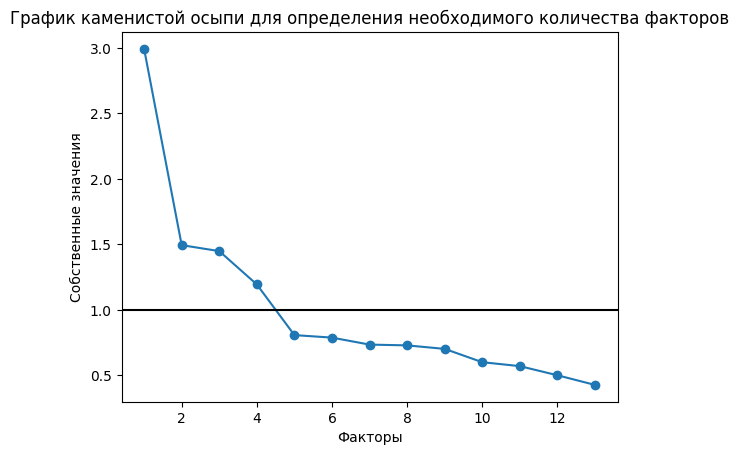

In [ ]:
plt.scatter(range(1,df_clean.shape[1]+1),ev)
plt.plot(range(1,df_clean.shape[1]+1),ev)
plt.title('График каменистой осыпи для определения необходимого количества факторов')
plt.xlabel('Факторы')
plt.ylabel('Собственные значения')
plt.axhline(y=1,c='k');

При визуальном анализе видно, что оптимальное количество факторов = 4.

Факторный анализ с 4 факторами

In [ ]:
fa = FactorAnalyzer()
fa.set_params(n_factors=4, rotation='varimax') #количество факторов - 4, метод вращения - веримакс
fa.fit(df_clean)
loadings = fa.loadings_ #получение факторных нагрузок
loadings = np.abs(loadings)

#Создаем датафрейм с факторами и переменными
df_fa = pd.DataFrame(
    loadings,
    index=df_clean.columns.tolist(),
    columns=[f'F{i+1}' for i in range(4)]
)

print(df_fa)

                         F1        F2        F3        F4
Age                0.039963  0.120627  0.563687  0.031121
Glucose            0.106295  0.725881  0.082552  0.086789
Blood Pressure     0.144433  0.006830  0.619261  0.059505
BMI                0.554342  0.048839  0.009612  0.091883
Oxygen Saturation  0.032014  0.041096  0.109383  0.439749
LengthOfStay       0.097522  0.252886  0.091389  0.504101
Cholesterol        0.269990  0.040430  0.352308  0.143602
Triglycerides      0.374374  0.016833  0.214968  0.086219
HbA1c              0.189383  0.729690  0.014564  0.085314
Physical Activity  0.658470  0.195494  0.104488  0.099077
Diet Score         0.576318  0.290801  0.172093  0.191671
Stress Level       0.032545  0.046284  0.340928  0.379988
Sleep Hours        0.113611  0.075913  0.155165  0.468242


Видно, что к F1 можно отнести BMI (индекс массы тела), Triglycerides (уровень триглицеридов), Physical Activity (физическая активность), Diet Score (показатель диеты).

К F2 можно отнести Glucose (глюкоза), HbA1c (гликированный гемоглобин).

К F3 относятся Age (возраст), Blood Pressure (артериальное давление), Cholesterol (холестерин).

К F4 относятся Oxygen Saturation (уровень насыщения кислородом в крови), LengthOfStay (дни, проведённые в больнице), Stress Level (уровень стресса), Sleep Hours (количество часов сна).

А теперь построим heatmap факторных нагрузок для F1.

In [ ]:
#Подготовка данных к визуализации
df_fa['Max_Factor'] = df_fa.idxmax(axis=1)
df_fa['Max_Value'] = df_fa[[f'F{i+1}' for i in range(4)]].max(axis=1)
df_fa_sorted = df_fa.sort_values(by=['Max_Factor', 'Max_Value'], ascending=[True, False])
df_fa_sorted = df_fa_sorted.drop(columns=['Max_Factor', 'Max_Value'])

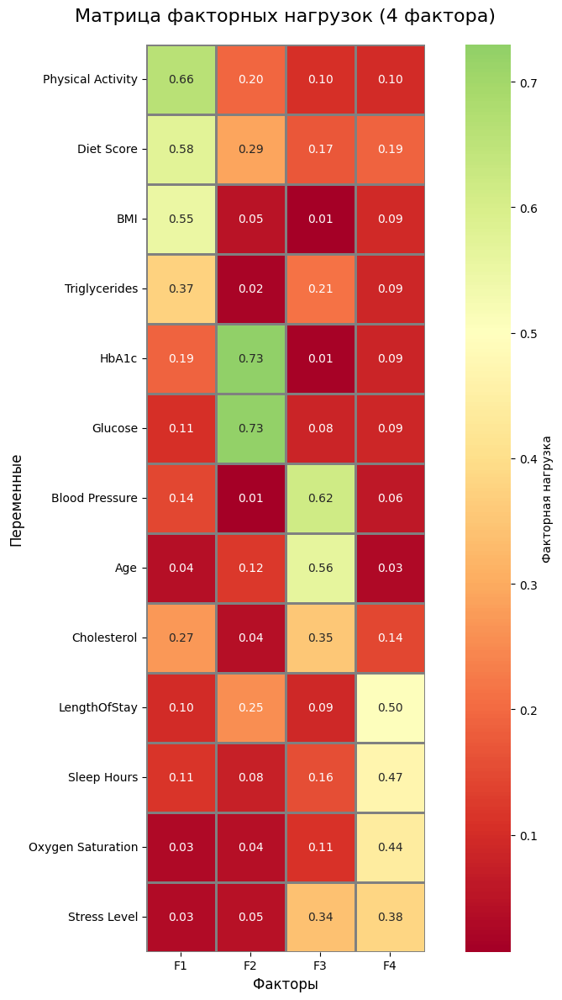

In [ ]:
plt.figure(figsize=(10, 12))

sns.heatmap(
    df_fa_sorted,
    annot=True,
    fmt='.2f',
    linewidths=1,
    linecolor='gray',
    cmap='RdYlGn',
    center=0.5,
    square=True,
    cbar_kws={'label': 'Факторная нагрузка'},
    annot_kws={'size': 10}
)

plt.title('Матрица факторных нагрузок (4 фактора)', fontsize=16, pad=20)
plt.xlabel('Факторы', fontsize=12)
plt.ylabel('Переменные', fontsize=12)

plt.tight_layout()
plt.show()

Здесь видно связь переменных с факторами.

Оставим 4 фактора и проведём анализ с ними. Также добавим вращения.

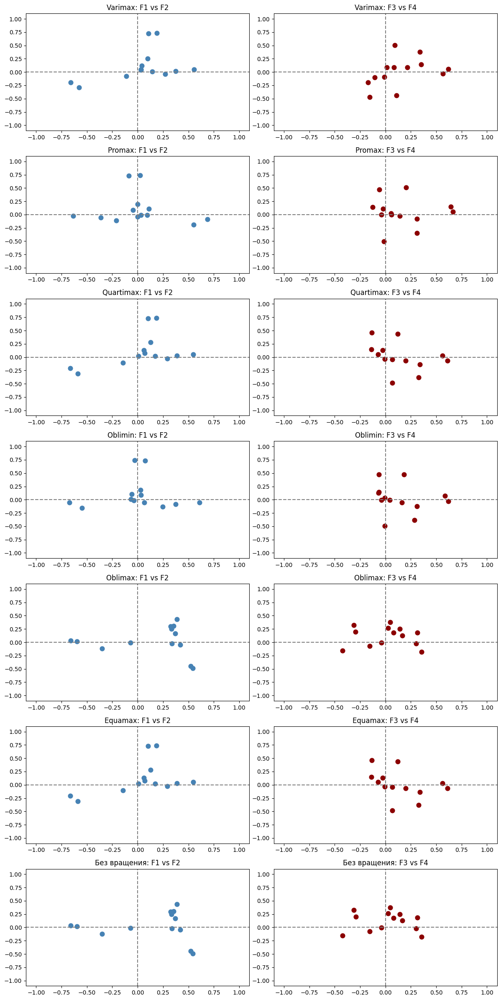

In [ ]:
rotation_methods = ['varimax', 'promax', 'quartimax', 'oblimin', 'oblimax', 'equamax', None]
rotation_names = ['Varimax', 'Promax', 'Quartimax', 'Oblimin', 'Oblimax', 'Equamax', 'Без вращения']

fig, axes = plt.subplots(len(rotation_methods), 2, figsize=(12, 24))

for idx, (method, name) in enumerate(zip(rotation_methods, rotation_names)):
    fa4 = FactorAnalyzer(n_factors=4, rotation=method)
    fa4.fit(df_clean)
    load = fa4.loadings_

    # График 1: F1 vs F2
    ax = axes[idx, 0]
    ax.scatter(load[:,0], load[:,1], c='steelblue', s=60)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-1.1,1.1); ax.set_ylim(-1.1,1.1)
    ax.set_title(f"{name}: F1 vs F2")

    # График 2: F3 vs F4
    ax = axes[idx, 1]
    ax.scatter(load[:,2], load[:,3], c='darkred', s=60)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-1.1,1.1); ax.set_ylim(-1.1,1.1)
    ax.set_title(f"{name}: F3 vs F4")

plt.tight_layout()
plt.show()


Исходя из графиков, методы без вращения, equamax, promax, quatrimax - не лучшие, они слабые , потому что в них переменные группируются плохо, факторы не отделяются.
Остальные методы дают более чёткую и интерпретируемую картинку факторов.

Построим матрицу факторных нагрузок для 4 факторов

In [ ]:
fa_4 = FactorAnalyzer()
fa_4.set_params(n_factors=4)
fa_4.fit(df_clean)

# исходные нагрузки
loadings_4 = fa_4.loadings_

# берём абсолютные значения, как у преподавателя
loadings_4 = np.abs(loadings_4)

# ---- Создаём датафрейм ----
df_fa_4 = pd.DataFrame(
    loadings_4,
    index=df_clean.columns.tolist(),
    columns=[f'F{i+1}' for i in range(4)]
)

print(df_fa_4)

                         F1        F2        F3        F4
Age                0.112516  0.107251  0.643206  0.151313
Glucose            0.024173  0.739688  0.057291  0.001515
Blood Pressure     0.002537  0.041933  0.663824  0.057758
BMI                0.636605  0.026592  0.125929  0.143810
Oxygen Saturation  0.044220  0.084154  0.201973  0.508886
LengthOfStay       0.000056  0.193053  0.013277  0.503855
Cholesterol        0.212717  0.113200  0.311418  0.078658
Triglycerides      0.362757  0.058569  0.140341  0.027193
HbA1c              0.087376  0.732686  0.040227  0.002821
Physical Activity  0.685183  0.087160  0.055627  0.022666
Diet Score         0.550226  0.188842  0.024465  0.108198
Stress Level       0.092066  0.009326  0.310655  0.348287
Sleep Hours        0.034122  0.005000  0.061664  0.469905


Замечаем, что для каждого фактора есть свои переменные. Их количество примерно равно для каждого из них. Следовательно, распределение нормально, ровно.

Посчитаем количество факторов для каждого наблюдения

In [ ]:
factor_scores = pd.DataFrame(
    np.dot(df_clean.values, df_fa_4.values),
    index=df_clean.index,
    columns=df_fa_4.columns  # ['F1', 'F2', 'F3', 'F4']
)

# Добавляем их в основной df_clean
df_clean[['F1', 'F2', 'F3', 'F4']] = factor_scores

df_clean


,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Physical Activity,Diet Score,Stress Level,Sleep Hours,F1,F2,F3,F4
0,-1.998159,-1.464767,-1.252450,-0.358383,0.862352,-0.834106,-1.401411,-0.960444,-1.003768,2.071592,0.952518,-0.017274,1.214593,0.795685,-2.032273,-2.486107,0.165687
1,0.707195,-0.666067,1.752925,0.477023,0.117151,-0.105600,1.356365,-1.237532,-0.131627,-0.197450,-0.403414,0.212962,0.315876,-0.122009,-0.446378,1.970884,0.529400
2,-0.276570,-0.264514,1.457944,-0.524427,0.204656,0.258653,0.580630,0.557001,-0.539169,0.524066,0.274552,0.605716,0.074554,0.488309,-0.304119,1.219437,0.547888
3,-2.551527,-0.820249,-0.622201,0.151855,0.980906,0.622906,-0.583412,-0.260776,0.031390,0.653441,0.806078,0.533485,-0.707662,0.531850,-0.547338,-1.914530,0.314009
4,-1.383306,-0.013416,-0.802338,-0.595341,0.345792,-1.198360,-1.749508,-0.834569,-1.117880,0.479282,1.305060,-1.132334,1.439272,-0.303013,-1.191128,-2.355518,-0.498569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11371,0.891651,-0.812117,0.450750,-0.712955,0.455879,4.265438,-1.428707,-0.138989,-1.794400,1.449596,-1.894938,0.262620,-0.474661,-0.904176,-1.359342,0.435113,2.013372
11372,-1.321821,0.174653,-0.137822,0.828136,-0.681681,0.258653,0.159744,-0.671913,-0.604376,-1.028437,-0.099685,-0.297167,-0.225018,-0.704911,-0.580216,-1.196350,-0.555928
11373,-0.030629,-0.964266,-0.585155,-0.010730,-0.035276,-1.198360,0.155047,-0.482079,-1.052673,2.584117,3.366077,-1.019474,2.038417,3.327820,-0.896071,-0.514399,0.358498
11374,-0.829938,-0.866335,0.650800,-0.593611,0.447411,-0.105600,-0.440768,0.008138,-0.636979,-0.306922,-0.403414,0.366452,-2.871239,-1.113754,-1.331055,-0.389127,-1.308630


# Регрессия (сравнение без факторов и с факторами)

Построим регрессию с факторами F1, F2, F3 и F4

Проверяем длительность пребывания в больнице, отвечая на вопрос "Могут ли скрытые ффакторы объяснить, сколько дней человек провёл в больнице?"

In [ ]:
#Определим целевую переменную и независимые переменные
y = df_clean['LengthOfStay']
x = df_clean[['F1', 'F2', 'F3', 'F4']]

In [ ]:
# линейния регрессия с 4 фактором
model = LinearRegression()
model.fit(x, y)

print("Коэффициенты модели:")
print(f"Свободный член: {model.intercept_:.4f}")
for i in range(4):
    print(f"F{i+1}: {model.coef_[i]:.4f}")


Коэффициенты модели:
Свободный член: -0.0000
F1: -0.2337
F2: 0.2196
F3: -0.0986
F4: 0.5078


F4 - самый сильный фактор, который увеличивает длительность пребывания.

F1 и F3 имеют отрицательные влияния.

F2 - немного положительный.

In [ ]:
# оценка качества модели
predictions = model.predict(x)
df_clean['Predictions'] = predictions

r2 = r2_score(y, predictions)
mse = mean_squared_error(y, predictions)

print(f"\nКоэффициент детерминации: {r2:.4f}")
print(f"Среднеквадратичная ошибка: {mse:.4f}")



Коэффициент детерминации: 0.3219
Среднеквадратичная ошибка: 0.6781


Модель объясняет около 32% вариации длительности пребывания. Это нормально, потому что длительность пребывания зависит от сотен факторов, которые в таблице не отражены: тяжесть заболевания, осложнения, индивидуальные реакции (на них был сделан акцент при подсчёте выбросов) и так далее.

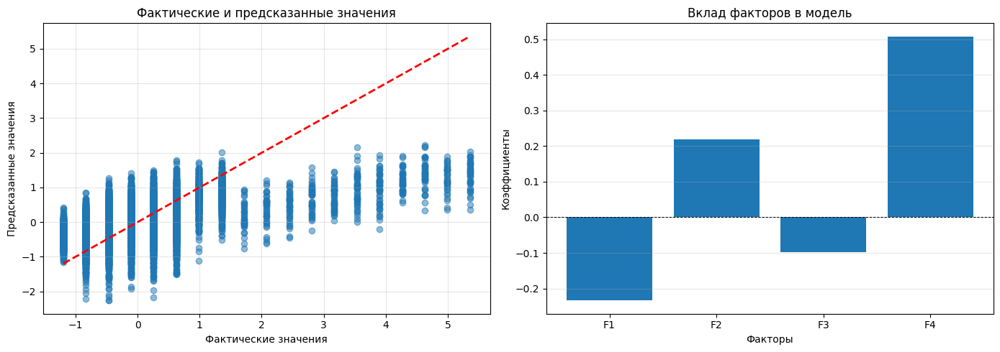

In [ ]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График фактических и предсказанных значений
axes[0].scatter(y, predictions, alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)

axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Фактические и предсказанные значения')
axes[0].grid(True, alpha=0.3)

# 2. График вклада факторов
factors = ['F1', 'F2', 'F3', 'F4']
coefs = model.coef_

axes[1].bar(factors, coefs)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.7)

axes[1].set_xlabel('Факторы')
axes[1].set_ylabel('Коэффициенты')
axes[1].set_title('Вклад факторов в модель')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Без факторов

In [ ]:
#Определим целевую переменную и независимые переменные
y_2 = df_clean['LengthOfStay']
x_2 = df_clean.drop(columns=['LengthOfStay', 'F1', 'F2', 'F3', 'F4', 'Predictions'], axis = 1)

In [ ]:
model_2 = LinearRegression()
model_2.fit(x_2, y_2)

print("Коэффициенты модели без факторов:")
print(f"Свободный член: {model_2.intercept_:.4f}")
for i, col in enumerate(x_2.columns):
    print(f"{col}: {model_2.coef_[i]:.4f}")

Коэффициенты модели без факторов:
Свободный член: 0.0000
Age: 0.0456
Glucose: 0.0914
Blood Pressure: -0.0878
BMI: -0.0679
Oxygen Saturation: -0.1178
Cholesterol: 0.0222
Triglycerides: -0.0008
HbA1c: 0.1030
Physical Activity: -0.0662
Diet Score: -0.1269
Stress Level: 0.2032
Sleep Hours: -0.1499


In [ ]:
# Оценка качества
predictions_2 = model_2.predict(x_2)
df_clean['Predictions_2'] = predictions_2

r2_2 = r2_score(y_2, predictions_2)
mse_2 = mean_squared_error(y_2, predictions_2)

print("\nКоэффициент детерминации:", round(r2_2, 4))
print("Среднеквадратичная ошибка:", round(mse_2, 4))


Коэффициент детерминации: 0.212
Среднеквадратичная ошибка: 0.788


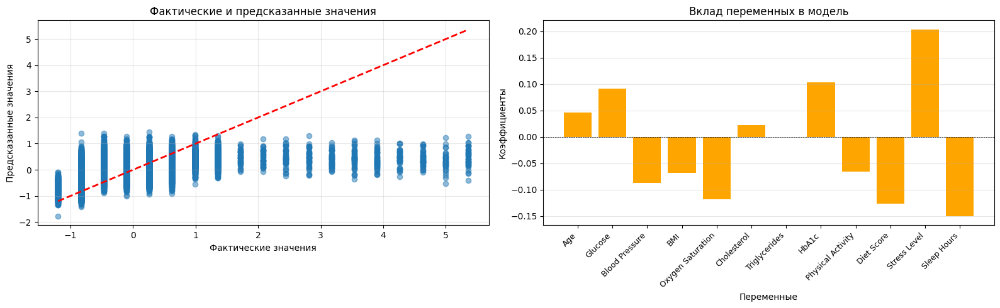

In [ ]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# График фактических и предсказанных значений
axes[0].scatter(y_2, predictions_2, alpha=0.5)

# Линия идеального предсказания
axes[0].plot([y_2.min(), y_2.max()],
             [y_2.min(), y_2.max()],
             'r--', lw=2)

axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Фактические и предсказанные значения')
axes[0].grid(True, alpha=0.3)


# График вклада переменных
factors = x_2.columns.tolist()  # имена переменных
coefs = model_2.coef_           # коэффициенты регрессии

axes[1].bar(factors, coefs, color='orange')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

axes[1].set_xticklabels(factors, rotation=45, ha='right', fontsize=9)
axes[1].set_xlabel('Переменные')
axes[1].set_ylabel('Коэффициенты')
axes[1].set_title('Вклад переменных в модель')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Качество последней модели без факторов оказалось заметно хуже. Только 21% вариации объясняет длительность пребывания в больнице. Это говорит о том, что исходные переменные слабее описывают зависимость.
Кроме того, коэффициенты для отдельных переменных показывают слабые и разнонаправленные влияния, что говорит о том, что модель размазана и не может выделить устойчивые зависимости.


# Вывод

В итоге, для анализа и прогнозирования длительности пребывания в больницу пациентов целесообразно использовать факторный анализ, которые обеспечивает более высокий уровень объяснения и отражает скрытую структуру данных.